In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path('/content/drive/MyDrive/wakacyjne/llm/02') # change path here!

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [9]:
titanic_df = pd.read_csv(base_path / 'titanic_ready.csv', index_col='PassengerId')

In [11]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,2,0,0.0,0.0,1.0
2,1,1,1,38.0,1,0,71.2833,2,0,1.0,0.0,0.0
3,1,3,1,26.0,0,0,7.9250,1,1,0.0,0.0,1.0
4,1,1,1,35.0,1,0,53.1000,2,0,0.0,0.0,1.0
5,0,3,0,35.0,0,0,8.0500,1,1,0.0,0.0,1.0


* Tabela jest moją końcową z zadania 1, z wykresów w poprzednim zadaniu można było zauważyć, że ważnymi kolumnami dla przeżywalności była Sex (Płeć), Pclass (Klasa biletu)
* Kolumna Cabin została usunięta z powodu dużej liczby braków a Name i Ticket odrzuciłem z powodu małej zależności
* Kolumny Age i Fare uzupełniłem medianą, z czego już wiem, że w Age mogłem użyć mediany z warunkami co dałoby jeszcze lepsze wyniki a te dwie kolumny pomimo braków okazują się bardzo ważne w ocenie przeżywalności
*

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

y = titanic_df['Survived']
X = titanic_df.drop('Survived', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dummy_model = DummyClassifier(strategy='uniform', random_state=42)
dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

print(classification_report(y_test, y_pred_dummy))

print("\nMacierz pomyłek:")
print(confusion_matrix(y_test, y_pred_dummy))

              precision    recall  f1-score   support

           0       0.54      0.44      0.48       105
           1       0.37      0.47      0.42        74

    accuracy                           0.45       179
   macro avg       0.46      0.46      0.45       179
weighted avg       0.47      0.45      0.46       179


Macierz pomyłek:
[[46 59]
 [39 35]]


Możemy zauważyć, że DummyClassifier ma skuteczność na poziomie 0.45 czyli 45% dlatego przy implentowaniu Drzewa Decyzyjnego i KNN będzie mi zależało uzyskać wyższy wynik od 0.45
# 1 Drzewo decyzyjne

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
print("Basic Drzewo decyzyjne:")
print(classification_report(y_test, y_pred_tree))

Basic Drzewo decyzyjne:
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       105
           1       0.71      0.74      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



In [20]:
parameters = {
    'max_depth': [2, 3, 5, 7, 10],
    'min_samples_leaf': [1, 3, 5, 10],
    'criterion': ['gini', 'entropy']
}
find_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    parameters,
    cv=5,
    scoring='accuracy'
)
find_tree.fit(X_train, y_train)

print("Naj parametry:")
print(find_tree.best_params_)
print("Accuracy dla tych parametrów:", round(find_tree.best_score_, 3))


Naj parametry:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5}
Accuracy dla tych parametrów: 0.824


In [21]:
y_pred_best_tree = find_tree.predict(X_test)
print("Podrasowane drzewo:")
print(classification_report(y_test, y_pred_best_tree))
print("\nMacierz pomyłek:")
print(confusion_matrix(y_test, y_pred_best_tree))

Podrasowane drzewo:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


Macierz pomyłek:
[[92 13]
 [22 52]]


Z racji że nie do końca wiedziałem jakie paraemetry wybrać znazałem kilka doo drzewa decyzyjnego które wydawały się dla mnie sensowne:
- max_depth - ponieważ pomaga nam uniknąć przetrenowania modelu, zadając dużą liczbę pytań do oceny przeżywalności w moim przypadku wystarczą 3.
- min_samples_leaf - wybrałem również ten hiperparametr z racji, że zapobiega on tworzeniu pojedynczych specyficznychh liści na samym dole drzewa. W przypadku mojego modelu najlepiej żeby to było 5.
- criterion - Uznałem to również za ważny hiperparametr z racji że są dwa do wyboru to łatwo będzie ocenić który z tych dwóch bardziej się nada ale wybór bardziej losowy tego parametru. Okazazło się, że pomiędzy funkcjami gini i entropy to entropy okazał się zwyciezcą w tym przypadku.

# KNN
Na początku pracy z KNN muszę skalować dane, ponieważ w przypadku tego algorytmu dane o wysokim zakresie liczbowym takim jak w tym przypadku cena totalnie zdominuje nad pozostałymi jak płeć lub wielkości krewnych.

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

knn_pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier())

grid_knn = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan', 'cosine']
}
find_knn = GridSearchCV(
    knn_pipeline,
    grid_knn,
    cv=5,
    scoring='accuracy'
)

find_knn.fit(X_train, y_train)

print("Najlepsze parametry:")
print(find_knn.best_params_)
print("Accuracy dla tych parametrów:", round(find_knn.best_score_, 3))

Najlepsze parametry:
{'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__weights': 'uniform'}
Accuracy dla tych parametrów: 0.816


In [26]:
y_pred_knn = find_knn.predict(X_test)
print("KNN końcowe")
print(classification_report(y_test, y_pred_knn))
print("\nMacierz pomyłek dla KNN:")
print(confusion_matrix(y_test, y_pred_knn))

KNN końcowe
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       105
           1       0.83      0.73      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.82       179


Macierz pomyłek dla KNN:
[[94 11]
 [20 54]]


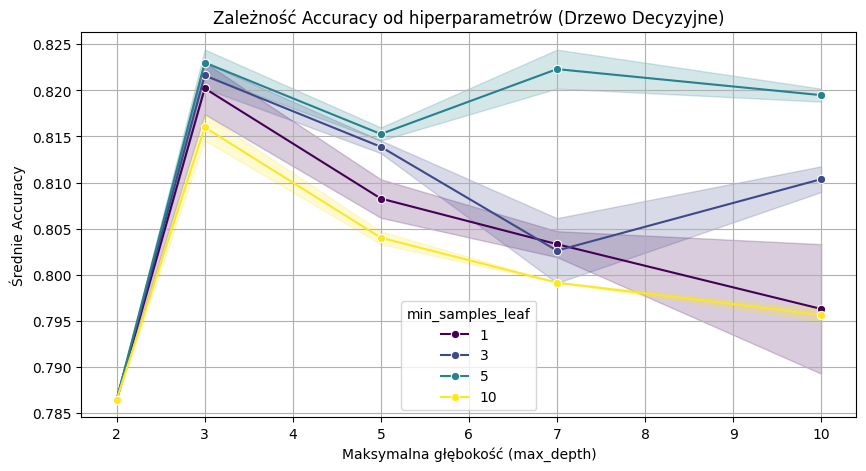

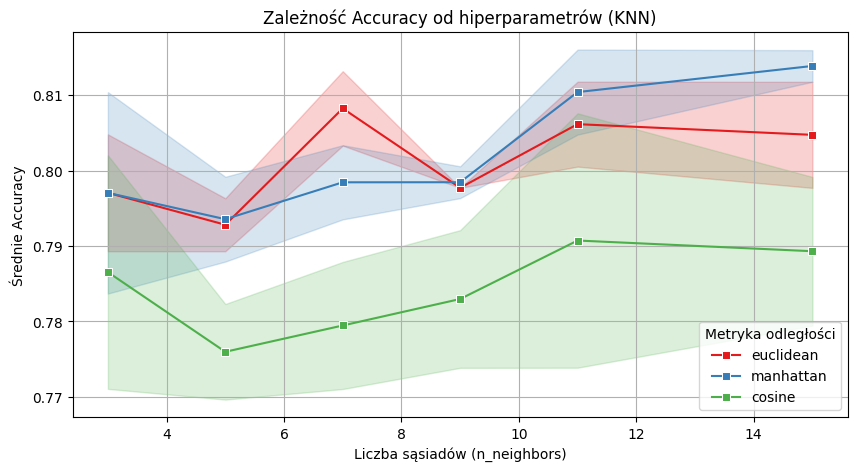

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

tree_results = pd.DataFrame(find_tree.cv_results_)

plt.figure(figsize=(10, 5))
sns.lineplot(data=tree_results, x='param_max_depth', y='mean_test_score',
             hue='param_min_samples_leaf', marker='o', palette='viridis')
plt.title('Zależność Accuracy od hiperparametrów (Drzewo Decyzyjne)')
plt.xlabel('Maksymalna głębokość (max_depth)')
plt.ylabel('Średnie Accuracy')
plt.legend(title='min_samples_leaf')
plt.grid(True)
plt.show()


knn_results = pd.DataFrame(find_knn.cv_results_)

plt.figure(figsize=(10, 5))
sns.lineplot(data=knn_results, x='param_kneighborsclassifier__n_neighbors',
             y='mean_test_score', hue='param_kneighborsclassifier__metric',
             marker='s', palette='Set1')
plt.title('Zależność Accuracy od hiperparametrów (KNN)')
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Średnie Accuracy')
plt.legend(title='Metryka odległości')
plt.grid(True)
plt.show()

#Wnioski
W moim przypadku Alogrytm KNN jest lepszy od Drzewa decyzyjnego. Algorytm KNN uzyskał 83% dokładności, a Drzewo Decyzyjne 80% dokładności, jednkaże nie sa az tak duze roznice procentowe, poniewaz oba osiagnely wysoki wynik w porownaniu do dummy clasiffier. Ciekawym zjawiskiem jest to ze dummy osiagnął 45% gdzie przy zgadywaniu 0 albo 1 powinno wystapic 50% ale z racji na nierowne pule przezywalnosci, czyli wiecej osob nie przezylo niz przezylo to nasz procent spada w dol gdyz zbiory nie sa idealnie rowne. Dodatkowo dla mnie osobiscie Algorytm KNN wydaje sie przyjemniejszy i bardziej logiczny od drzewa decyzyjnego stad bardziej mi podpasował. Dodatkowo w przypadku wykresów widzimy, że dla min_samples_leaf praktycznie cały czas dominuje wartość 5 w porównaniu do pozostałych. Za to w przypadku KNN metryki odległości nie mamy jednoznacznego dominanta. Można zauważyć, że cosine cały czas utrzymuje się na niskiej dokładności za to mocno rywalizuje euklides i manhatan z delikatną przewagą manhatana, chociaż dla euklidesa i pomiędzy 6 a 8 sąsiadami prawie dorównuje manhatanowi w dokładności.

In [37]:
import pandas as pd

dane_pasazera = pd.DataFrame([{
    'Pclass': 2,
    'Sex': 0,
    'Age': 22.0,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 30.0,
    'FamilySize': 2,
    'IsAlone': 0,
    'Embarked_C': 0.0,
    'Embarked_Q': 0.0,
    'Embarked_S': 1.0
}])

wynik = find_knn.predict(dane_pasazera)

szanse = find_knn.predict_proba(dane_pasazera)

if wynik[0] == 1:
    print(f"Twoje szanse według KNN to: {szanse[0][1]*100:.1f}%")
else:
    print(f"Twoje szanse na przeżycie to: {szanse[0][1]*100:.1f}%")

Twoje szanse na przeżycie to: 9.1%


In [36]:
import pandas as pd

dane_pasazera = pd.DataFrame([{
    'Pclass': 2,
    'Sex': 1,
    'Age': 21.0,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 31.0,
    'FamilySize': 2,
    'IsAlone': 0,
    'Embarked_C': 0.0,
    'Embarked_Q': 0.0,
    'Embarked_S': 1.0
}])

wynik = find_knn.predict(dane_pasazera)

szanse = find_knn.predict_proba(dane_pasazera)

if wynik[0] == 1:
    print(f"Twoje szanse według KNN to: {szanse[0][1]*100:.1f}%")
else:
    print(f"Twoje szanse na przeżycie to: {szanse[0][1]*100:.1f}%")

Twoje szanse według KNN to: 63.6%
